# MEG brain-state classification — INFOMDLR Project 2 (restructured)

Logical top-down flow: **setup → data → preprocessing → models → self-test →
CV-tune-all → final training → multi-seed → results**. Run top to bottom.

- **Validate cheaply:** set `SMOKE = True` in the config cell → the whole notebook
  (incl. CV and multi-seed) runs in minutes at tiny epochs/folds/seeds. Confirms every
  loop works before any long run.
- **Canonical run:** set `SMOKE = False` → full CV + training + multi-seed.
- **Device:** auto-detects CUDA → MPS → CPU; force one via the commented toggles in Setup.
  The faithful AA / mesh CascadeFormer are MPS-safe (no grouped convs); only the EEG
  Conformer's depthwise conv can misbehave on MPS, should be run on CUDA/CPU.


In [1]:
import sys, math, random, time
from pathlib import Path
from collections import defaultdict

import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.signal import decimate, butter, sosfiltfilt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LambdaLR

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

# --- Device: auto-detect (CUDA > Apple MPS > CPU). To force one, uncomment a line. ---
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
# device = torch.device("cuda")  # force NVIDIA GPU (RTX 4070 / RTX 2070)
# device = torch.device("mps")   # force Apple GPU (M1)
# device = torch.device("cpu")   # force CPU - use on M1 if MPS misbehaves (see EEG Conformer note)

print("device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("python  :", sys.executable)
print("pytorch :", torch.__version__)


device: cuda
GPU: NVIDIA GeForce RTX 4070 Ti SUPER
python  : D:\DL_ASSIGNMENT2\.venv\Scripts\python.exe
pytorch : 2.12.0+cu126


## Run configuration

One flag (`SMOKE`) scales every long loop. Same hyperparameter grid for all models.

In [2]:
# Flip to validate the whole notebook top-down in minutes; set False for the canonical run.
SMOKE = False

CV_GRID  = [(lr, do) for lr in (1e-3, 3e-4, 1e-4) for do in (0.3, 0.5)]   # same grid for ALL models
PATIENCE = 10

if SMOKE:
    CV_FOLDS, CV_EPOCHS = 2, 2
    AA_EPOCHS = CF_EPOCHS = CONF_EPOCHS = 2
    SEEDS = [0, 1]
else:
    CV_FOLDS, CV_EPOCHS = 4, 25
    AA_EPOCHS, CF_EPOCHS, CONF_EPOCHS = 40, 50, 60
    SEEDS = [0, 1, 2, 3, 4]

print(f"SMOKE={SMOKE} | CV {CV_FOLDS}fold x {CV_EPOCHS}ep | "
      f"final epochs AA/CF/Conf = {AA_EPOCHS}/{CF_EPOCHS}/{CONF_EPOCHS} | seeds={SEEDS}")


SMOKE=False | CV 4fold x 25ep | final epochs AA/CF/Conf = 40/50/60 | seeds=[0, 1, 2, 3, 4]


## Looking at one file first

Before writing any preprocessing it's worth opening one of the recordings and
checking what's actually in there — the assignment hints at the format but I'd
rather see it.

In [3]:
# --- Data directory for THIS machine. Uncomment the line for the machine you run on. ---
# DATA_DIR = Path("/Users/ydobergstra/Desktop/Documenten/Studie/AI 25-26/Deep_Learning/Final Project data")  # Ydo (M1 / RTX 2070)
DATA_DIR = Path(r"D:\DL_ASSIGNMENT2\data")  # groupmate (RTX 4070) - raw string avoids the \D SyntaxWarning
assert DATA_DIR.exists(), f"DATA_DIR not found: {DATA_DIR}"

sample_path = sorted((DATA_DIR / "Intra" / "train").glob("*.h5"))[0]
with h5py.File(sample_path, "r") as f:
    key = list(f.keys())[0]
    arr = f[key][()]
print(f"file        : {sample_path.name}")
print(f"hdf5 dataset: {key!r}")
print(f"shape       : {arr.shape}  (channels, samples)")
print(f"dtype       : {arr.dtype}")
print(f"value range : [{arr.min():.2e}, {arr.max():.2e}]   (raw MEG is ~1e-12 T)")


file        : rest_105923_1.h5
hdf5 dataset: 'rest_105923'
shape       : (248, 35624)  (channels, samples)
dtype       : float64
value range : [-2.79e-11, 1.32e-11]   (raw MEG is ~1e-12 T)


So each file holds a single recording, `(248 channels, 35624 samples)`. With
the published sampling rate of 2034 Hz that's about 17.5 seconds of brain data.
The HDF5 key is the filename minus the trailing chunk number — useful to know,
because reading the file requires that key.

Let's plot a few channels just to see what the signal looks like.

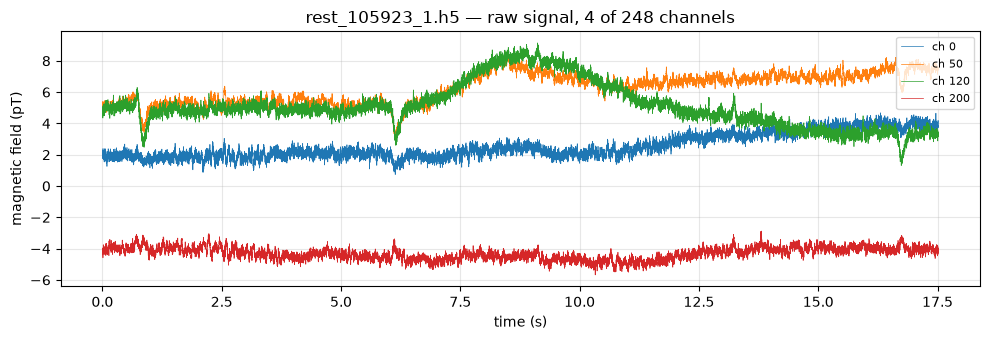

In [4]:
FS_ORIG = 2034
t = np.arange(arr.shape[1]) / FS_ORIG
fig, ax = plt.subplots(figsize=(10, 3.5))
for ch in (0, 50, 120, 200):
    ax.plot(t, arr[ch] * 1e12, lw=0.5, label=f"ch {ch}")
ax.set_xlabel("time (s)"); ax.set_ylabel("magnetic field (pT)")
ax.set_title(f"{sample_path.name} — raw signal, 4 of 248 channels")
ax.legend(loc="upper right", fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Preprocessing

Four things to do per file:

1. **Compute in float64, store in float32**. The raw values are in tesla so
   they're tiny (~1e-12). The decimation, band-pass and per-channel mean/std are
   done in **float64** - accumulating those in float32 loses significant figures
   at this scale - and only the final normalised array is cast down to
   **float32** for memory and speed.
2. **Decimate by a factor of 8**, from 2034 Hz to ~254 Hz. The interesting
   neural rhythms for these tasks live well below 100 Hz so the new Nyquist
   (~127 Hz) is more than enough. `scipy.signal.decimate` includes the
   anti-alias filter for free.
3. **Band-pass [1, 45] Hz** (zero-phase Butterworth via `scipy.signal.sosfiltfilt`).
   This keeps the brain rhythms (delta through low-gamma) and removes sub-1 Hz
   drift and everything above 45 Hz - including the 50 Hz line noise that the
   anti-alias low-pass (cutoff ~127 Hz) leaves untouched. This brings us in line
   with MEG practice (Zubarev et al., 2019, band-pass 1-45 Hz) and the EEG
   Conformer's [4, 40] Hz band. Set `BANDPASS = None` to fall back to
   decimate-only.
4. **Z-score each channel**. Mean/std are taken in float64 because at the
   ~1e-12 scale, accumulating in float32 costs significant figures in the std
   estimate. Dead channels (zero variance) are left at zero rather than getting
   an epsilon, so they stay obviously dead.

Preprocessing is the expensive bit, so I cache the result per file (keyed by the
band-pass setting). The same file gets re-windowed many times during CV and
across the Intra/Cross sections.


In [5]:
DOWNSAMPLE_FACTOR = 8
FS_DOWN = FS_ORIG // DOWNSAMPLE_FACTOR   # ~254 Hz

# Band-pass applied to the decimated signal. (low_hz, high_hz); set to None for
# decimate-only. [1, 45] Hz keeps brain rhythms, drops <1 Hz drift and >45 Hz
# (incl. 50 Hz line noise) -- consistent with Zubarev (2019) MEG / Song (2023) EEG.
BANDPASS = None #(1.0, 45.0)

def get_dataset_name(p: Path) -> str:
    return "_".join(Path(p).stem.split("_")[:-1])

def load_meg_file(p: Path) -> np.ndarray:
    with h5py.File(p, "r") as f:
        return f[get_dataset_name(p)][()]

def downsample(x, factor=DOWNSAMPLE_FACTOR):
    return decimate(x, q=factor, axis=-1, ftype="iir", zero_phase=True)

def bandpass_filter(x, fs=FS_DOWN, band=None, order=4):
    if band is None:
        return x
    lo, hi = band
    sos = butter(order, [lo, hi], btype="band", fs=fs, output="sos")
    return sosfiltfilt(sos, x, axis=-1)

def normalize_per_channel(x):
    x64 = x.astype(np.float64)
    mean = x64.mean(axis=-1, keepdims=True)
    std = x64.std(axis=-1, keepdims=True)
    std = np.where(std == 0.0, 1.0, std)
    return ((x64 - mean) / std).astype(np.float32)

def preprocess(x):
    # raw -> decimate (anti-alias) -> optional band-pass -> per-channel z-score
    return normalize_per_channel(bandpass_filter(downsample(x.astype(np.float64)), band=BANDPASS))

_CACHE = {}
def preprocess_file(p: Path) -> np.ndarray:
    p = Path(p)
    key = (p, BANDPASS)          # cache invalidated automatically if BANDPASS changes
    if key not in _CACHE:
        _CACHE[key] = preprocess(load_meg_file(p))
    return _CACHE[key]


Sanity check — after preprocessing every channel should have mean ~0, std 1.

In [6]:
xp = preprocess_file(sample_path)
print(f"preprocessed shape : {xp.shape}   ({FS_DOWN} Hz)")
print(f"per-channel mean   : in [{xp.mean(-1).min():.1e}, {xp.mean(-1).max():.1e}]")
print(f"per-channel std    : in [{xp.std(-1).min():.3f}, {xp.std(-1).max():.3f}]")

preprocessed shape : (248, 4453)   (254 Hz)
per-channel mean   : in [-5.5e-08, 5.5e-08]
per-channel std    : in [1.000, 1.000]


## Windowing

Each preprocessed recording is sliced into fixed-length windows. With
`win_seconds = 1.0` that's 254 samples per window, and at non-overlapping
stride you get 17 windows per file. Each window inherits its file's label
because every recording has a single sustained task condition — there is no
event-locked structure to worry about.

The `stride` argument lets me reuse this for overlapping windows, which is
how I want to augment the training set. **Important**: I only ever overlap on
training data; validation and test stay non-overlapping so the metric isn't
inflated by adjacent, correlated windows.

In [7]:
WIN_SECONDS = 1.0
WIN_SAMPLES = int(WIN_SECONDS * FS_DOWN)

LABEL_MAP = {"rest": 0, "task_motor": 1, "task_story_math": 2, "task_working_memory": 3}
CLASS_NAMES = ["rest", "motor", "math", "memory"]

def label_from_filename(p) -> int:
    stem = Path(p).stem
    for prefix in sorted(LABEL_MAP, key=len, reverse=True):
        if stem.startswith(prefix + "_"):
            return LABEL_MAP[prefix]
    raise ValueError(f"unknown task prefix: {p}")

def make_windows(x, win_samples=WIN_SAMPLES, stride=None):
    if stride is None:
        stride = win_samples
    n_ch, n_t = x.shape
    n_win = (n_t - win_samples) // stride + 1
    out = np.empty((n_win, n_ch, win_samples), dtype=np.float32)
    for i in range(n_win):
        s = i * stride
        out[i] = x[:, s:s + win_samples]
    return out

def build_from_files(files, win_samples=WIN_SAMPLES, stride=None, verbose=False):
    Xs, ys, wpf = [], [], None
    for f in files:
        w = make_windows(preprocess_file(f), win_samples=win_samples, stride=stride)
        if wpf is None:
            wpf = len(w)
        Xs.append(w)
        ys.append(np.full(len(w), label_from_filename(f), dtype=np.int64))
    X = np.concatenate(Xs, 0).astype(np.float32)
    y = np.concatenate(ys, 0)
    if verbose:
        print(f"  {len(files):>2d} files -> X {X.shape}, y {y.shape}, {wpf} win/file")
    return X, y, wpf

class MEGWindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

Concrete check on the augmentation idea: how many windows do I gain by halving
the stride? Getting around 2x more gradient steps is a real lift on a tiny dataset. windows are highly correlated, so effective info gain is less than 2x. main benefit is desner sampling of the loss landscape, not independent extra data


In [8]:
# 17 windows/file at full stride; ~34 at half-stride.
n_nonoverlap = make_windows(xp, win_samples=WIN_SAMPLES, stride=WIN_SAMPLES).shape[0]
n_overlap    = make_windows(xp, win_samples=WIN_SAMPLES, stride=WIN_SAMPLES // 2).shape[0]
print(f"non-overlapping windows per file : {n_nonoverlap}")
print(f"50% overlap windows per file     : {n_overlap}")

non-overlapping windows per file : 17
50% overlap windows per file     : 34


## File-level train/val/test split

The pitfall here is splitting *windows* — adjacent windows from the same
recording are correlated, so any window-level split leaks. The clean solution
is to split whole files, stratified by class, and only then window them.

For Intra I hold out 2 files per class (8 of 32 train files) as validation.
The `Intra/test` folder is set aside and not used until the final evaluation.

In [9]:
def stratified_file_split(files, val_per_class=2, seed=SEED):
    by_cls = defaultdict(list)
    for f in files:
        by_cls[label_from_filename(f)].append(f)
    rng = random.Random(seed)
    tr, va = [], []
    for cls, fs in sorted(by_cls.items()):
        fs = sorted(fs); rng.shuffle(fs)
        va += fs[:val_per_class]; tr += fs[val_per_class:]
    return sorted(tr), sorted(va)

intra_train_files_all = sorted((DATA_DIR / "Intra" / "train").glob("*.h5"))
intra_tr_files, intra_val_files = stratified_file_split(intra_train_files_all, val_per_class=2)
print(f"intra train files: {len(intra_tr_files)}   val files: {len(intra_val_files)}")
for f in intra_val_files:
    print("  val:", f.name)

intra train files: 24   val files: 8
  val: rest_105923_4.h5
  val: rest_105923_5.h5
  val: task_motor_105923_4.h5
  val: task_motor_105923_8.h5
  val: task_story_math_105923_4.h5
  val: task_story_math_105923_6.h5
  val: task_working_memory_105923_2.h5
  val: task_working_memory_105923_3.h5


## Datasets & loaders

Intra window arrays (channel×time); cross window arrays. Mesh loaders are built per-model later (the mesh models reshape these same arrays).

In [10]:
TRAIN_STRIDE = WIN_SAMPLES // 2   # 50% overlap on training
EVAL_STRIDE  = WIN_SAMPLES        # no overlap on val/test
BATCH_SIZE   = 32

X_tr, y_tr, WPF_TR  = build_from_files(intra_tr_files, stride=TRAIN_STRIDE, verbose=True)
X_val, y_val, WPF_E = build_from_files(intra_val_files, stride=EVAL_STRIDE, verbose=True)
X_te,  y_te,  _     = build_from_files(sorted((DATA_DIR / "Intra" / "test").glob("*.h5")),
                                       stride=EVAL_STRIDE, verbose=True)

intra_tr_loader  = DataLoader(MEGWindowDataset(X_tr, y_tr),   batch_size=BATCH_SIZE, shuffle=True)
intra_val_loader = DataLoader(MEGWindowDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
intra_te_loader  = DataLoader(MEGWindowDataset(X_te,  y_te),  batch_size=BATCH_SIZE, shuffle=False)

  24 files -> X (816, 248, 254), y (816,), 34 win/file
   8 files -> X (136, 248, 254), y (136,), 17 win/file
   8 files -> X (136, 248, 254), y (136,), 17 win/file


In [11]:
# Cross-subject window arrays (train on 2 subjects, test on 3 unseen). Loaders built per-model.
cross_train_files_all = sorted((DATA_DIR / "Cross" / "train").glob("*.h5"))
cr_tr_files, cr_val_files = stratified_file_split(cross_train_files_all, val_per_class=4)
print(f"cross train files: {len(cr_tr_files)}   val files: {len(cr_val_files)}")

Xc_tr,  yc_tr,  _ = build_from_files(cr_tr_files,  stride=TRAIN_STRIDE, verbose=True)
Xc_val, yc_val, _ = build_from_files(cr_val_files, stride=EVAL_STRIDE,  verbose=True)

cross_test = {}   # name -> (X, y, win_per_file)
for name in ("test1", "test2", "test3"):
    Xt, yt, wpf = build_from_files(sorted((DATA_DIR / "Cross" / name).glob("*.h5")), stride=EVAL_STRIDE)
    cross_test[name] = (Xt, yt, wpf)


cross train files: 48   val files: 16
  48 files -> X (1632, 248, 254), y (1632,), 34 win/file
  16 files -> X (272, 248, 254), y (272,), 17 win/file


## Training & evaluation utilities

`fit` selects the best-validation epoch; `kfold_file_indices` powers CV; `warmup_cosine` is the Transformer schedule.

In [12]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    tl = tc = tn = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        tl += loss.item() * xb.size(0)
        tc += (logits.argmax(1) == yb).sum().item()
        tn += xb.size(0)
    return tl / tn, tc / tn

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    tl = tc = tn = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        tl += loss.item() * xb.size(0)
        tc += (logits.argmax(1) == yb).sum().item()
        tn += xb.size(0)
    return tl / tn, tc / tn

def fit(model, train_loader, val_loader, n_epochs=30, lr=1e-3, weight_decay=0.0,
        optimizer=None, scheduler=None, patience=10, verbose=True):
    criterion = nn.CrossEntropyLoss()
    if optimizer is None:
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    hist = defaultdict(list)
    best_val_acc, best_state, best_epoch = 0.0, None, 0
    for ep in range(1, n_epochs + 1):
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer)
        vl, va = evaluate(model, val_loader, criterion)
        if scheduler is not None:
            scheduler.step()
        hist["train_loss"].append(tl); hist["train_acc"].append(ta)
        hist["val_loss"].append(vl);   hist["val_acc"].append(va)
        if va > best_val_acc:
            best_val_acc, best_epoch = va, ep
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if verbose:
            print(f"epoch {ep:3d} | train {tl:.3f}/{ta:.3f} | val {vl:.3f}/{va:.3f}")
        if ep - best_epoch >= patience:
            if verbose:
                print(f"  early stop at epoch {ep} (best was epoch {best_epoch}, val acc {best_val_acc:.3f})")
            break
    if verbose:
        print(f"best val acc: {best_val_acc:.3f} (epoch {best_epoch})")
    return hist, best_state, best_val_acc


crit = nn.CrossEntropyLoss()

def warmup_cosine(optimizer, n_epochs, warmup=5):
    def f(ep):
        if ep < warmup:
            return (ep + 1) / warmup
        p = (ep - warmup) / max(1, (n_epochs - warmup))
        return 0.5 * (1 + math.cos(math.pi * p))
    return LambdaLR(optimizer, f)


In [13]:
@torch.no_grad()
def predict_probs(model, X, batch_size=256):
    model.eval()
    out = []
    for i in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[i:i + batch_size]).float().to(device)
        out.append(torch.softmax(model(xb), 1).cpu().numpy())
    return np.concatenate(out, 0)

def file_level_accuracy(model, X, y, win_per_file):
    # NOTE: assumes every file contributes exactly `win_per_file` windows - the
    # reshape below relies on it. True here: all recordings have the same length,
    # so each yields 17 non-overlapping eval windows. Unequal-length files would
    # need per-file grouping instead.
    probs = predict_probs(model, X)
    n_files = len(X) // win_per_file
    fp = probs.reshape(n_files, win_per_file, -1).mean(1).argmax(1)
    fl = y[::win_per_file]
    return float((fp == fl).mean()), fp, fl

def per_class_accuracy(y_true, y_pred, n_classes=4):
    accs = []
    for c in range(n_classes):
        mask = (y_true == c)
        accs.append(float((y_pred[mask] == c).mean()) if mask.any() else float("nan"))
    return accs

def confusion_matrix(y_true, y_pred, n_classes=4):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def plot_confusion(cm, title, class_names=CLASS_NAMES, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(4.2, 3.8))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=30)
    ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(title)
    vmax = cm.max() if cm.max() > 0 else 1
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > vmax * 0.55 else "black", fontsize=9)
    return ax


In [14]:
def kfold_file_indices(files, k=4, seed=SEED):
    by_cls = defaultdict(list)
    for i, f in enumerate(files):
        by_cls[label_from_filename(f)].append(i)
    rng = random.Random(seed)
    folds = [[] for _ in range(k)]
    for cls, idxs in sorted(by_cls.items()):
        idxs = idxs[:]; rng.shuffle(idxs)
        for j, idx in enumerate(idxs):
            folds[j % k].append(idx)
    return folds


## Mesh pipeline (faithful AA-CascadeNet / mesh CascadeFormer)

The verbatim sensor→mesh map, vectorised, plus the per-window stream builder and a Dataset.

In [15]:
# ---- Verbatim sensor->mesh map from Mehrkanoon et al. (their data_utils.array_to_mesh) ----
def array_to_mesh(arr):    

    input_rows = 20
    input_columns = 21
    input_channels = 248

    assert arr.shape == (1,input_channels),"the shape of the input array should be (1,248) because there are 248 MEG channels,received array of shape " + str(arr.shape)
    output = np.zeros((input_rows,input_columns),dtype = np.float64)
    
    #121
    output[0][10] = arr[0][120]
      
    #89
    output[1][12] = arr[0][151]
    output[1][11] = arr[0][119]
    output[1][10] = arr[0][88]
    output[1][9] = arr[0][89]
    output[1][8] = arr[0][121]
    
    #61
    output[2][13] = arr[0][150]
    output[2][12] = arr[0][118]
    output[2][11] = arr[0][87]
    output[2][10] = arr[0][60]
    output[2][9] = arr[0][61]
    output[2][8] = arr[0][90]
    output[2][7] = arr[0][122]
    
    #37
    output[3][14] = arr[0][149]
    output[3][13] = arr[0][117]
    output[3][12] = arr[0][86]
    output[3][11] = arr[0][59]
    output[3][10] = arr[0][36]
    output[3][9] = arr[0][37]
    output[3][8] = arr[0][62]
    output[3][7] = arr[0][91]
    output[3][6] = arr[0][123]
    
    #19
    output[4][17] = arr[0][194]
    output[4][16] = arr[0][175]
    output[4][15] = arr[0][148]
    output[4][14] = arr[0][116]
    output[4][13] = arr[0][85]
    output[4][12] = arr[0][58]
    output[4][11] = arr[0][35]
    output[4][10] = arr[0][18]
    output[4][9] = arr[0][19]
    output[4][8] = arr[0][38]
    output[4][7] = arr[0][63]
    output[4][6] = arr[0][92]
    output[4][5] = arr[0][152]
    output[4][4] = arr[0][176]

    #5
    output[5][20] = arr[0][247]
    output[5][19] = arr[0][227]
    output[5][18] = arr[0][193]
    output[5][17] = arr[0][174]
    output[5][16] = arr[0][147]
    output[5][15] = arr[0][115]
    output[5][14] = arr[0][84]
    output[5][13] = arr[0][57]
    output[5][12] = arr[0][34]
    output[5][11] = arr[0][17]
    output[5][10] = arr[0][4]
    output[5][9] = arr[0][5]
    output[5][8] = arr[0][20]
    output[5][7] = arr[0][39]
    output[5][6] = arr[0][64]
    output[5][5] = arr[0][93]
    output[5][4] = arr[0][125]
    output[5][3] = arr[0][153]
    output[5][2] = arr[0][177]
    output[5][1] = arr[0][211]
    output[5][0] = arr[0][228]
    
    #4
    output[6][20] = arr[0][246]
    output[6][19] = arr[0][226]
    output[6][18] = arr[0][192]
    output[6][17] = arr[0][173]
    output[6][16] = arr[0][146]
    output[6][15] = arr[0][114]
    output[6][14] = arr[0][83]
    output[6][13] = arr[0][56]
    output[6][12] = arr[0][33]
    output[6][11] = arr[0][16]
    output[6][10] = arr[0][3]
    output[6][9] = arr[0][6]
    output[6][8] = arr[0][21]
    output[6][7] = arr[0][40]
    output[6][6] = arr[0][65]
    output[6][5] = arr[0][94]
    output[6][4] = arr[0][126]
    output[6][3] = arr[0][154]
    output[6][2] = arr[0][178]
    output[6][1] = arr[0][212]
    output[6][0] = arr[0][229]

    
    #3
    output[7][19] = arr[0][245]
    output[7][18] = arr[0][210]
    output[7][17] = arr[0][172]
    output[7][16] = arr[0][145]
    output[7][15] = arr[0][113]
    output[7][14] = arr[0][82]
    output[7][13] = arr[0][55]
    output[7][12] = arr[0][32]
    output[7][11] = arr[0][15]
    output[7][10] = arr[0][2]
    output[7][9] = arr[0][7]
    output[7][8] = arr[0][22]
    output[7][7] = arr[0][41]
    output[7][6] = arr[0][66]
    output[7][5] = arr[0][95]
    output[7][4] = arr[0][127]
    output[7][3] = arr[0][155]
    output[7][2] = arr[0][195]
    output[7][1] = arr[0][230]
            
    #8
    output[8][19] = arr[0][244]
    output[8][18] = arr[0][209]
    output[8][17] = arr[0][171]
    output[8][16] = arr[0][144]
    output[8][15] = arr[0][112]
    output[8][14] = arr[0][81]
    output[8][13] = arr[0][54]
    output[8][12] = arr[0][31]
    output[8][11] = arr[0][14]
    output[8][10] = arr[0][1]
    output[8][9] = arr[0][8]
    output[8][8] = arr[0][23]
    output[8][7] = arr[0][42]
    output[8][6] = arr[0][67]
    output[8][5] = arr[0][96]
    output[8][4] = arr[0][128]
    output[8][3] = arr[0][156]
    output[8][2] = arr[0][196]
    output[8][1] = arr[0][231]
    
    #1
    output[9][19] = arr[0][243]
    output[9][18] = arr[0][208]
    output[9][17] = arr[0][170]
    output[9][16] = arr[0][143]
    output[9][15] = arr[0][111]
    output[9][14] = arr[0][80]
    output[9][13] = arr[0][53]
    output[9][12] = arr[0][30]
    output[9][11] = arr[0][13]
    output[9][10] = arr[0][0]
    output[9][9] = arr[0][9]
    output[9][8] = arr[0][24]
    output[9][7] = arr[0][43]
    output[9][6] = arr[0][68]
    output[9][5] = arr[0][97]
    output[9][4] = arr[0][129]
    output[9][3] = arr[0][157]
    output[9][2] = arr[0][197]
    output[9][1] = arr[0][232]
    
    #12
    output[10][18] = arr[0][225]
    output[10][17] = arr[0][191]
    output[10][16] = arr[0][142]
    output[10][15] = arr[0][110]
    output[10][14] = arr[0][79]
    output[10][13] = arr[0][52]
    output[10][12] = arr[0][29]
    output[10][11] = arr[0][12]
    output[10][10] = arr[0][11]
    output[10][9] = arr[0][10]
    output[10][8] = arr[0][25]
    output[10][7] = arr[0][44]
    output[10][6] = arr[0][69]
    output[10][5] = arr[0][98]
    output[10][4] = arr[0][130]
    output[10][3] = arr[0][179]
    output[10][2] = arr[0][213]
    
    #28
    output[11][16] = arr[0][169]
    output[11][15] = arr[0][141]
    output[11][14] = arr[0][109]
    output[11][13] = arr[0][78]
    output[11][12] = arr[0][51]
    output[11][11] = arr[0][28]
    output[11][10] = arr[0][27]
    output[11][9] = arr[0][26]
    output[11][8] = arr[0][45]
    output[11][7] = arr[0][70]
    output[11][6] = arr[0][99]
    output[11][5] = arr[0][131]
    output[11][4] = arr[0][158]
    
    #49
    output[12][17] = arr[0][190]
    output[12][16] = arr[0][168]
    output[12][15] = arr[0][140]
    output[12][14] = arr[0][108]
    output[12][13] = arr[0][77]
    output[12][12] = arr[0][50]
    output[12][11] = arr[0][49]
    output[12][10] = arr[0][48]
    output[12][9] = arr[0][47]
    output[12][8] = arr[0][46]
    output[12][7] = arr[0][71]
    output[12][6] = arr[0][100]
    output[12][5] = arr[0][132]
    output[12][4] = arr[0][159]
    output[12][3] = arr[0][180]

    
    #75
    output[13][18] = arr[0][224]
    output[13][17] = arr[0][207]
    output[13][16] = arr[0][189]
    output[13][15] = arr[0][167]
    output[13][14] = arr[0][139]
    output[13][13] = arr[0][107]
    output[13][12] = arr[0][76]
    output[13][11] = arr[0][75]
    output[13][10] = arr[0][74]
    output[13][9] = arr[0][73]
    output[13][8] = arr[0][72]
    output[13][7] = arr[0][101]
    output[13][6] = arr[0][133]
    output[13][5] = arr[0][160]
    output[13][4] = arr[0][181]
    output[13][3] = arr[0][198]
    output[13][2] = arr[0][214]
    
    #105
    output[14][18] = arr[0][242]
    output[14][17] = arr[0][223]
    output[14][16] = arr[0][206]
    output[14][15] = arr[0][188]
    output[14][14] = arr[0][166]
    output[14][13] = arr[0][138]
    output[14][12] = arr[0][106]
    output[14][11] = arr[0][105]
    output[14][10] = arr[0][104]
    output[14][9] = arr[0][103]
    output[14][8] = arr[0][102]
    output[14][7] = arr[0][134]
    output[14][6] = arr[0][161]
    output[14][5] = arr[0][182]
    output[14][4] = arr[0][199]
    output[14][3] = arr[0][215]
    output[14][2] = arr[0][233]
    
    
    #137
    output[15][16] = arr[0][241]
    output[15][15] = arr[0][222]
    output[15][14] = arr[0][205]
    output[15][13] = arr[0][187]
    output[15][12] = arr[0][165]
    output[15][11] = arr[0][137]
    output[15][10] = arr[0][136]
    output[15][9] = arr[0][135]
    output[15][8] = arr[0][162]
    output[15][7] = arr[0][183]
    output[15][6] = arr[0][200]
    output[15][5] = arr[0][216]
    output[15][4] = arr[0][234]
    
    
    #mix
    output[16][15] = arr[0][240]
    output[16][14] = arr[0][221]
    output[16][13] = arr[0][204]
    output[16][12] = arr[0][186]
    output[16][11] = arr[0][164]
    output[16][10] = arr[0][163]
    output[16][9] = arr[0][184]
    output[16][8] = arr[0][201]
    output[16][7] = arr[0][217]
    output[16][6] = arr[0][235]
   
    #186
    output[17][12] = arr[0][220]
    output[17][11] = arr[0][203]
    output[17][10] = arr[0][185]
    output[17][9] = arr[0][202]
    output[17][8] = arr[0][218]
   
    #220
    output[18][11] = arr[0][239]
    output[18][10] = arr[0][219]
    output[18][9] = arr[0][236]
    
    #mix
    output[19][11] = arr[0][238]
    output[19][10] = arr[0][237]
    
    return output

# ---- Derive a vectorised (20x21) index map from the verbatim function (one probe call) ----
MESH_ROWS, MESH_COLS = 20, 21
MESH_W = 10           # window_size: number of streams
MESH_DEPTH = 25       # time-frames per stream; 10*25=250 tiles our 254-sample window
MESH_USE = MESH_W * MESH_DEPTH    # 250 frames used per 1-s window

_probe = (np.arange(248, dtype=np.float64).reshape(1, 248) + 1.0)   # channels 1..248
_m = array_to_mesh(_probe).astype(int) - 1                          # cell -> channel idx, -1 empty
MESH_IDX = np.where(_m < 0, 248, _m).astype(np.int64)               # empty -> pad row 248
assert (MESH_IDX < 248).sum() == 247, "expected 247 mapped cells (channel 124 is dropped)"

def window_to_streams(win):
    """(248, T>=250) preprocessed window -> (W=10, depth=25, 20, 21) float32 stream tensor."""
    w = win[:, :MESH_USE].astype(np.float32)                 # (248, 250)
    padded = np.concatenate([w, np.zeros((1, MESH_USE), np.float32)], axis=0)  # (249, 250)
    meshes = padded[MESH_IDX]                                # (20, 21, 250)
    meshes = np.transpose(meshes, (2, 0, 1))                 # (250, 20, 21)
    return meshes.reshape(MESH_W, MESH_DEPTH, MESH_ROWS, MESH_COLS)  # stream i = frames [i*25:(i+1)*25]

class MeshWindowDataset(Dataset):
    """Wraps existing (N, 248, T) window arrays; yields (10, 25, 20, 21) mesh tensors."""
    def __init__(self, X, y):
        self.X = X
        self.y = torch.from_numpy(y).long()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return torch.from_numpy(window_to_streams(self.X[i])), self.y[i]


In [16]:
# Mesh loaders reuse the SAME window arrays as the other models (same preprocessing/splits).
mesh_tr_loader  = DataLoader(MeshWindowDataset(X_tr,  y_tr),  batch_size=BATCH_SIZE, shuffle=True)
mesh_val_loader = DataLoader(MeshWindowDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
mesh_te_loader  = DataLoader(MeshWindowDataset(X_te,  y_te),  batch_size=BATCH_SIZE, shuffle=False)

@torch.no_grad()
def predict_probs_mesh(model, X, batch_size=64):
    model.eval()
    out = []
    for i in range(0, len(X), batch_size):
        xb = np.stack([window_to_streams(X[j]) for j in range(i, min(i + batch_size, len(X)))])
        out.append(torch.softmax(model(torch.from_numpy(xb).float().to(device)), 1).cpu().numpy())
    return np.concatenate(out, 0)

def file_level_accuracy_mesh(model, X, y, win_per_file):
    probs = predict_probs_mesh(model, X)
    n_files = len(X) // win_per_file
    fp = probs.reshape(n_files, win_per_file, -1).mean(1).argmax(1)
    fl = y[::win_per_file]
    return float((fp == fl).mean()), fp, fl

# fit() / evaluate() / train_one_epoch() are model-agnostic, so they work unchanged with the
# mesh loaders above. Only file-level aggregation needs the mesh-aware helper.


### Mesh sanity visualization

Quick visual check that the sensor-to-mesh transformation produces a plausible frame before the mesh models are defined.


Text(0.5, 1.0, 'one meshed frame')

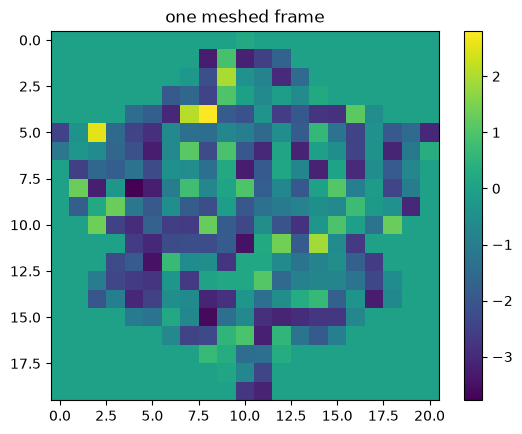

In [17]:
import matplotlib.pyplot as plt
plt.imshow(window_to_streams(X_te[0])[0, 0]); plt.colorbar(); plt.title("one meshed frame")

## Model definitions

**AA-CascadeNet** (faithful mesh) and **CascadeFormer** (same mesh stem, Transformer back-end — the one-factor swap); **EEG Conformer** (channel×time, published transformer baseline).

In [18]:
class AugmentedConv2d(nn.Module):
    """Bello et al. attention-augmented conv (relative=False), as in their tfaugmented_conv2d.
    Output channels = max(1, Fout-dv) regular-conv maps concatenated with dv attention maps."""
    def __init__(self, in_ch, Fout, k=7, dk=4, dv=2, Nh=2):
        super().__init__()
        self.dk, self.dv, self.Nh = dk, dv, Nh
        conv_filters = max(1, Fout - dv)
        self.conv = nn.Conv2d(in_ch, conv_filters, k, padding=k // 2)   # 'same' for odd k
        self.kqv = nn.Conv2d(in_ch, 2 * dk + dv, 1)
        self.attn_proj = nn.Conv2d(dv, dv, 1)
        self.out_ch = conv_filters + dv

    def forward(self, x):
        B, _, H, W = x.shape
        conv_out = self.conv(x)
        k, q, v = torch.split(self.kqv(x), [self.dk, self.dk, self.dv], dim=1)
        dkh, dvh = self.dk // self.Nh, self.dv // self.Nh
        q = q * (dkh ** -0.5)
        def heads(t, d):   # (B, d, H, W) -> (B, Nh, H*W, d//Nh)
            return t.reshape(B, self.Nh, d // self.Nh, H, W).permute(0, 1, 3, 4, 2).reshape(B, self.Nh, H * W, d // self.Nh)
        qh, kh, vh = heads(q, self.dk), heads(k, self.dk), heads(v, self.dv)
        weights = torch.softmax(torch.matmul(qh, kh.transpose(-1, -2)), dim=-1)   # (B,Nh,HW,HW)
        attn = torch.matmul(weights, vh)                                          # (B,Nh,HW,dvh)
        attn = attn.reshape(B, self.Nh, H, W, dvh).permute(0, 1, 4, 2, 3).reshape(B, self.Nh * dvh, H, W)
        attn = self.attn_proj(attn)
        return torch.cat([conv_out, attn], dim=1)

class SingleStem(nn.Module):
    """Per-stream feature extractor: augmented conv -> BN -> conv -> conv -> flatten -> dense."""
    def __init__(self, depth=MESH_DEPTH, c1=1, c2=2, c3=4, k=7, dense_nodes=125, dropout=0.5):
        super().__init__()
        self.aug = AugmentedConv2d(depth, c1, k)
        self.bn = nn.BatchNorm2d(self.aug.out_ch)
        self.conv2 = nn.Conv2d(self.aug.out_ch, c2, k, padding=k // 2)
        self.conv3 = nn.Conv2d(c2, c3, k, padding=k // 2)
        self.dense = nn.Linear(c3 * MESH_ROWS * MESH_COLS, dense_nodes)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):                  # (B, depth, 20, 21)
        x = self.bn(self.aug(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.drop(F.relu(self.dense(x.flatten(1))))
        return x                           # (B, 125)

class MeshStem(nn.Module):
    """window_size independent per-stream stems (unshared weights -> ~2.1M params)."""
    def __init__(self, W=MESH_W, depth=MESH_DEPTH, dropout=0.5):
        super().__init__()
        self.stems = nn.ModuleList([SingleStem(depth=depth, dropout=dropout) for _ in range(W)])

    def forward(self, x):                  # (B, W, depth, 20, 21)
        return torch.stack([s(x[:, i]) for i, s in enumerate(self.stems)], dim=1)   # (B, W, 125)

class AACascadeNetMesh(nn.Module):
    """Faithful AA-CascadeNet: mesh stem -> 2 unidirectional LSTMs -> Luong global attention."""
    def __init__(self, depth=MESH_DEPTH, dropout=0.5, dense_nodes=125, lstm_cells=10):
        super().__init__()
        self.stem = MeshStem(depth=depth, dropout=dropout)
        self.lstm1 = nn.LSTM(dense_nodes, lstm_cells, batch_first=True)
        self.lstm2 = nn.LSTM(lstm_cells, lstm_cells, batch_first=True)
        self.attn_score = nn.Linear(lstm_cells, lstm_cells, bias=False)
        self.attn_vec = nn.Linear(2 * lstm_cells, 128, bias=False)
        self.dense3 = nn.Linear(128, dense_nodes)
        self.final_drop = nn.Dropout(dropout)
        self.out = nn.Linear(dense_nodes, 4)

    def forward(self, x):
        h = self.stem(x)                       # (B, 10, 125)
        h, _ = self.lstm1(h)
        h, _ = self.lstm2(h)                   # (B, 10, lstm_cells)
        score = torch.bmm(self.attn_score(h), h[:, -1, :].unsqueeze(-1)).squeeze(-1)  # (B,10)
        w = torch.softmax(score, dim=1)
        context = torch.bmm(w.unsqueeze(1), h).squeeze(1)            # (B, lstm_cells)
        attn_vec = torch.tanh(self.attn_vec(torch.cat([context, h[:, -1, :]], dim=1)))  # (B,128)
        z = self.final_drop(F.relu(self.dense3(attn_vec)))
        return self.out(z)

class CascadeFormerMesh(nn.Module):
    """One-factor variant: identical mesh stem, Transformer back-end over the 10 stream-tokens."""
    def __init__(self, depth=MESH_DEPTH, dropout=0.5, dense_nodes=125,
                 d_model=64, n_heads=4, n_layers=3, ff_dim=128):
        super().__init__()
        self.stem = MeshStem(depth=depth, dropout=dropout)
        self.proj = nn.Linear(dense_nodes, d_model)
        self.pos = nn.Parameter(torch.randn(1, MESH_W, d_model) * 0.02)
        enc = nn.TransformerEncoderLayer(d_model, n_heads, ff_dim, dropout,
                                         activation="gelu", batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc, n_layers, enable_nested_tensor=False)
        self.out = nn.Linear(d_model, 4)

    def forward(self, x):
        h = self.proj(self.stem(x)) + self.pos
        return self.out(self.transformer(h).mean(dim=1))


In [19]:
class EEGConformer(nn.Module):
    """Song et al. (2023) EEG Conformer, adapted to 254-sample MEG windows.
    Depthwise (grouped) spatial conv -> Transformer encoder -> flatten classifier."""
    def __init__(self, n_channels=248, n_classes=4, embed_dim=40, temp_kernel=25,
                 pool_kernel=15, pool_stride=5, n_heads=4, n_layers=4,
                 ff_dim=128, dropout=0.3, win_samples=WIN_SAMPLES):
        super().__init__()
        self.temporal_conv = nn.Conv2d(1, embed_dim, (1, temp_kernel),
                                       padding=(0, temp_kernel // 2), bias=False)
        self.spatial_conv = nn.Conv2d(embed_dim, embed_dim, (n_channels, 1),
                                      groups=embed_dim, bias=False)   # depthwise
        self.bn = nn.BatchNorm2d(embed_dim)
        self.act = nn.ELU()
        self.pool = nn.AvgPool2d((1, pool_kernel), stride=(1, pool_stride))
        self.drop = nn.Dropout(dropout)
        with torch.no_grad():
            d = torch.zeros(1, 1, n_channels, win_samples)
            d = self.pool(self.act(self.bn(self.spatial_conv(self.temporal_conv(d)))))
            self.seq_len = d.shape[-1]
        enc = nn.TransformerEncoderLayer(embed_dim, n_heads, ff_dim, dropout,
                                         activation="gelu", batch_first=True,
                                         norm_first=True)
        self.transformer = nn.TransformerEncoder(enc, n_layers, enable_nested_tensor=False)
        self.classifier = nn.Linear(embed_dim * self.seq_len, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.temporal_conv(x)
        x = self.spatial_conv(x)
        x = self.drop(self.pool(self.act(self.bn(x))))
        x = x.squeeze(2).transpose(1, 2)          # (B, seq_len, embed_dim)
        x = self.transformer(x)
        x = x.flatten(1)
        return self.classifier(x)


### Compact ablation model definitions

Compact channel×time variants live with the other model definitions, but they are evaluated separately after the main three-model comparison.


In [20]:
class AACascadeNetCompact(nn.Module):
    """Compact channel×time AA-CascadeNet (~47k): CNN front-end + BiLSTM + additive attention."""
    def __init__(self, n_channels=248, n_classes=4, temp_kernel=25,
                 n_temp_filters=8, n_spatial_filters=16, pool_size=4,
                 lstm_hidden=32, attn_dim=32, dropout=0.5):
        super().__init__()
        self.temporal_conv = nn.Conv2d(1, n_temp_filters, (1, temp_kernel),
                                       padding=(0, temp_kernel // 2), bias=False)
        self.bn_temp = nn.BatchNorm2d(n_temp_filters)
        self.spatial_conv = nn.Conv2d(n_temp_filters, n_spatial_filters,
                                      (n_channels, 1), bias=False)
        self.bn_spatial = nn.BatchNorm2d(n_spatial_filters)
        self.pool = nn.AvgPool2d((1, pool_size))
        self.dropout_cnn = nn.Dropout(dropout)
        self.lstm = nn.LSTM(n_spatial_filters, lstm_hidden,
                            batch_first=True, bidirectional=True)
        self.attn_W = nn.Linear(lstm_hidden * 2, attn_dim)
        self.attn_v = nn.Linear(attn_dim, 1, bias=False)
        self.classifier = nn.Linear(lstm_hidden * 2, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.bn_temp(self.temporal_conv(x))
        x = F.elu(self.bn_spatial(self.spatial_conv(x)))
        x = self.dropout_cnn(self.pool(x))
        x = x.squeeze(2).transpose(1, 2)
        x, _ = self.lstm(x)
        scores = self.attn_v(torch.tanh(self.attn_W(x)))
        weights = F.softmax(scores, dim=1)
        context = (x * weights).sum(dim=1)
        return self.classifier(context)


class CascadeFormerCompact(nn.Module):
    """Compact channel×time CascadeFormer (~138k): same CNN front-end, Transformer back-end."""
    def __init__(self, n_channels=248, n_classes=4, temp_kernel=25,
                 n_temp_filters=8, n_spatial_filters=16, pool_size=4,
                 d_model=64, n_heads=4, n_layers=3, ff_dim=128,
                 dropout=0.3, win_samples=WIN_SAMPLES):
        super().__init__()
        self.temporal_conv = nn.Conv2d(1, n_temp_filters, (1, temp_kernel),
                                       padding=(0, temp_kernel // 2), bias=False)
        self.bn_temp = nn.BatchNorm2d(n_temp_filters)
        self.spatial_conv = nn.Conv2d(n_temp_filters, n_spatial_filters,
                                      (n_channels, 1), bias=False)
        self.bn_spatial = nn.BatchNorm2d(n_spatial_filters)
        self.pool = nn.AvgPool2d((1, pool_size))
        self.dropout_cnn = nn.Dropout(dropout)
        self.proj = nn.Linear(n_spatial_filters, d_model)
        self.seq_len = win_samples // pool_size
        self.pos_embed = nn.Parameter(torch.randn(1, self.seq_len, d_model) * 0.02)
        enc = nn.TransformerEncoderLayer(d_model, n_heads, ff_dim, dropout,
                                         activation="gelu", batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc, n_layers, enable_nested_tensor=False)
        self.classifier = nn.Linear(d_model, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.bn_temp(self.temporal_conv(x))
        x = F.elu(self.bn_spatial(self.spatial_conv(x)))
        x = self.dropout_cnn(self.pool(x))
        x = x.squeeze(2).transpose(1, 2)
        x = self.proj(x) + self.pos_embed
        x = self.transformer(x)
        return self.classifier(x.mean(dim=1))


for _name, _M in [("AA-CascadeNet (compact)", AACascadeNetCompact()),
                  ("CascadeFormer (compact)", CascadeFormerCompact())]:
    print(f"{_name:26s} {sum(p.numel() for p in _M.parameters()):,} params")

AA-CascadeNet (compact)    47,164 params
CascadeFormer (compact)    137,788 params


## Self-test — run first

This cell checks that all model variants accept the expected input shape, produce 4-class logits, and have plausible parameter counts before any training starts. The mesh models use `(batch, time, depth, rows, cols)`, while the compact models use the normal channel×time format `(batch, channels, samples)`.

In [21]:
# ===== SELF-TEST: validates shapes + param count before any training (run this first) =====

# --- Mesh models: input shape is (batch, time, depth, rows, cols) ---
_xb_mesh = torch.randn(2, MESH_W, MESH_DEPTH, MESH_ROWS, MESH_COLS)

for name, M in [
    ("AA-CascadeNet (mesh)", AACascadeNetMesh()),
    ("CascadeFormer (mesh)", CascadeFormerMesh()),
]:
    M.eval()
    with torch.no_grad():
        out = M(_xb_mesh)

    n = sum(p.numel() for p in M.parameters() if p.requires_grad)
    assert out.shape == (2, 4), f"{name}: bad output shape {out.shape}"
    print(f"{name:28s} | out {tuple(out.shape)} | params {n:,}")

assert (MESH_IDX < 248).sum() == 247

# faithful AA should land near Mehrkanoon's reported 2,139,869 params
_aa_params = sum(p.numel() for p in AACascadeNetMesh().parameters())
assert 2_000_000 < _aa_params < 2_300_000, f"AA param count {_aa_params:,} off (expected ~2.14M)"


# --- Compact models: input shape is (batch, channels, samples) ---
_xb_compact = torch.randn(2, 248, WIN_SAMPLES)

for name, M in [
    ("AA-CascadeNet (compact)", AACascadeNetCompact()),
    ("CascadeFormer (compact)", CascadeFormerCompact()),
]:
    M.eval()
    with torch.no_grad():
        out = M(_xb_compact)

    n = sum(p.numel() for p in M.parameters() if p.requires_grad)
    assert out.shape == (2, 4), f"{name}: bad output shape {out.shape}"
    print(f"{name:28s} | out {tuple(out.shape)} | params {n:,}")

# Compact model parameter-count sanity checks.
# These are intentionally ranges instead of exact hard-codes, so small architecture tweaks
# do not break the test unnecessarily.
_aa_compact_params = sum(p.numel() for p in AACascadeNetCompact().parameters())
_cf_compact_params = sum(p.numel() for p in CascadeFormerCompact().parameters())

assert 40_000 < _aa_compact_params < 60_000, (
    f"AA compact param count {_aa_compact_params:,} off (expected ~47k)"
)
assert 120_000 < _cf_compact_params < 160_000, (
    f"CascadeFormer compact param count {_cf_compact_params:,} off (expected ~138k)"
)

print(f"\nmesh map OK (247 cells, channel 124 dropped); AA params {_aa_params:,} ~ paper's 2,139,869")
print(f"compact params OK; AA compact {_aa_compact_params:,}, CascadeFormer compact {_cf_compact_params:,}")
print("forward passes OK -> all models are wired correctly.")

AA-CascadeNet (mesh)         | out (2, 4) | params 2,148,799
CascadeFormer (mesh)         | out (2, 4) | params 2,232,530
AA-CascadeNet (compact)      | out (2, 4) | params 47,164
CascadeFormer (compact)      | out (2, 4) | params 137,788

mesh map OK (247 cells, channel 124 dropped); AA params 2,148,799 ~ paper's 2,139,869
compact params OK; AA compact 47,164, CascadeFormer compact 137,788
forward passes OK -> all models are wired correctly.


## Training and evaluation runs

This cell performs CV tuning, final intra/cross training, multi-seed evaluation, and the compact-model ablation. The final reporting tables are kept in the results section below.

In [22]:
# Per-model spec: factory, input type (mesh vs channel-time), optimiser recipe, final epochs.
MODELS = {
    "AA-CascadeNet": dict(factory=lambda do: AACascadeNetMesh(dropout=do), mesh=True,  adamw=False, epochs=AA_EPOCHS),
    "CascadeFormer": dict(factory=lambda do: CascadeFormerMesh(dropout=do), mesh=True,  adamw=True,  epochs=CF_EPOCHS),
    "EEG Conformer": dict(factory=lambda do: EEGConformer(dropout=do),      mesh=False, adamw=True,  epochs=CONF_EPOCHS),
}

def make_loader(X, y, mesh, shuffle, bs=BATCH_SIZE):
    ds = MeshWindowDataset(X, y) if mesh else MEGWindowDataset(X, y)
    return DataLoader(ds, batch_size=bs, shuffle=shuffle)

def train_one(spec, tr_loader, val_loader, lr, dropout, n_epochs, seed=SEED):
    torch.manual_seed(seed)
    model = spec["factory"](dropout).to(device)
    if spec["adamw"]:
        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        sch = warmup_cosine(opt, n_epochs, warmup=min(5, max(1, n_epochs // 5)))
        hist, state, val = fit(model, tr_loader, val_loader, n_epochs=n_epochs,
                               optimizer=opt, scheduler=sch, patience=PATIENCE, verbose=False)
    else:
        hist, state, val = fit(model, tr_loader, val_loader, n_epochs=n_epochs,
                               lr=lr, patience=PATIENCE, verbose=False)
    model.load_state_dict(state)
    return model, hist, val

def cv_tune(spec, files):
    folds = kfold_file_indices(files, k=CV_FOLDS)
    out = {}
    for lr, do in CV_GRID:
        accs = []
        for fi in range(CV_FOLDS):
            vix = set(folds[fi])
            trf = [files[i] for i in range(len(files)) if i not in vix]
            vaf = [files[i] for i in range(len(files)) if i in vix]
            Xtr, ytr, _ = build_from_files(trf, stride=TRAIN_STRIDE)
            Xva, yva, _ = build_from_files(vaf, stride=EVAL_STRIDE)
            _, _, val = train_one(spec, make_loader(Xtr, ytr, spec["mesh"], True),
                                  make_loader(Xva, yva, spec["mesh"], False), lr, do, CV_EPOCHS)
            accs.append(val)
        out[(lr, do)] = (float(np.mean(accs)), float(np.std(accs)))
    best = max(out, key=lambda k: out[k][0])
    return out, best

cv_results, cv_picks = {}, {}
for name, spec in MODELS.items():
    res, best = cv_tune(spec, intra_train_files_all)
    cv_results[name], cv_picks[name] = res, best
    print(f"\n{name} — {CV_FOLDS}-fold CV on the shared grid:")
    for (lr, do), (m, s) in res.items():
        mark = " *" if (lr, do) == best else "  "
        print(f"  {mark} lr={lr:.0e}  dropout={do}  ->  {m:.3f} +/- {s:.3f}")
    print(f"   picked: lr={best[0]:.0e}, dropout={best[1]}")


def file_level(model, X, y, wpf, mesh):
    return (file_level_accuracy_mesh if mesh else file_level_accuracy)(model, X, y, wpf)

def eval_intra(model, mesh):
    _, win = evaluate(model, make_loader(X_te, y_te, mesh, False), crit)
    fa, _, _ = file_level(model, X_te, y_te, WPF_E, mesh)
    return win, fa

def eval_cross(model, mesh):
    wins, files = {}, {}
    for nm, (Xt, yt, wpf) in cross_test.items():
        _, wins[nm] = evaluate(model, make_loader(Xt, yt, mesh, False), crit)
        files[nm], _, _ = file_level(model, Xt, yt, wpf, mesh)
    return wins, files

final = {}
for name, spec in MODELS.items():
    lr, do = cv_picks[name]
    m_i, _, val_i = train_one(spec, make_loader(X_tr, y_tr, spec["mesh"], True),
                              make_loader(X_val, y_val, spec["mesh"], False), lr, do, spec["epochs"])
    win_i, file_i = eval_intra(m_i, spec["mesh"])
    m_c, _, val_c = train_one(spec, make_loader(Xc_tr, yc_tr, spec["mesh"], True),
                              make_loader(Xc_val, yc_val, spec["mesh"], False), lr, do, spec["epochs"])
    cw, cfl = eval_cross(m_c, spec["mesh"])
    final[name] = dict(val_i=val_i, win_i=win_i, file_i=file_i, val_c=val_c,
                       cross_win=cw, cross_file=cfl,
                       cwin=float(np.mean(list(cw.values()))), cfile=float(np.mean(list(cfl.values()))))
    print(f"{name:14s} | Intra val {val_i:.3f} win {win_i:.3f} file {file_i:.3f} "
          f"| Cross avg win {final[name]['cwin']:.3f} file {final[name]['cfile']:.3f}")


def mean_std(xs):
    xs = np.asarray(xs, float); return float(xs.mean()), float(xs.std())

multiseed = {}
for name, spec in MODELS.items():
    lr, do = cv_picks[name]
    acc = {"val_i": [], "win_i": [], "file_i": [], "cwin": [], "cfile": []}
    for s in SEEDS:
        mi, _, vi = train_one(spec, make_loader(X_tr, y_tr, spec["mesh"], True),
                              make_loader(X_val, y_val, spec["mesh"], False), lr, do, spec["epochs"], seed=s)
        wi, fi = eval_intra(mi, spec["mesh"])
        mc, _, _ = train_one(spec, make_loader(Xc_tr, yc_tr, spec["mesh"], True),
                             make_loader(Xc_val, yc_val, spec["mesh"], False), lr, do, spec["epochs"], seed=s)
        cw, cfl = eval_cross(mc, spec["mesh"])
        acc["val_i"].append(vi); acc["win_i"].append(wi); acc["file_i"].append(fi)
        acc["cwin"].append(np.mean(list(cw.values()))); acc["cfile"].append(np.mean(list(cfl.values())))
    multiseed[name] = {k: mean_std(v) for k, v in acc.items()}
    a = multiseed[name]
    print(f"{name:14s} | Intra file {a['file_i'][0]:.3f}+/-{a['file_i'][1]:.3f} "
          f"| Cross file {a['cfile'][0]:.3f}+/-{a['cfile'][1]:.3f} (over seeds {SEEDS})")


# Same machinery, same grid/seeds/band-pass as the main run -> directly comparable.
COMPACT_MODELS = {
    "AA-CascadeNet (compact)": dict(factory=lambda do: AACascadeNetCompact(dropout=do), mesh=False, adamw=False, epochs=AA_EPOCHS),
    "CascadeFormer (compact)": dict(factory=lambda do: CascadeFormerCompact(dropout=do), mesh=False, adamw=True,  epochs=CF_EPOCHS),
}

compact_cv, compact_final, compact_multiseed = {}, {}, {}
for name, spec in COMPACT_MODELS.items():
    res, best = cv_tune(spec, intra_train_files_all)
    compact_cv[name] = best
    lr, do = best
    print(f"\n{name}: CV pick lr={lr:.0e} dropout={do}")

    m_i, _, val_i = train_one(spec, make_loader(X_tr, y_tr, False, True),
                              make_loader(X_val, y_val, False, False), lr, do, spec["epochs"])
    win_i, file_i = eval_intra(m_i, False)
    m_c, _, val_c = train_one(spec, make_loader(Xc_tr, yc_tr, False, True),
                              make_loader(Xc_val, yc_val, False, False), lr, do, spec["epochs"])
    cw, cfl = eval_cross(m_c, False)
    compact_final[name] = dict(val_i=val_i, win_i=win_i, file_i=file_i, val_c=val_c,
                               cwin=float(np.mean(list(cw.values()))), cfile=float(np.mean(list(cfl.values()))))
    print(f"  Intra val {val_i:.3f} win {win_i:.3f} file {file_i:.3f} | "
          f"Cross win {compact_final[name]['cwin']:.3f} file {compact_final[name]['cfile']:.3f}")

    acc = {"file_i": [], "cfile": []}
    for s in SEEDS:
        mi, _, _ = train_one(spec, make_loader(X_tr, y_tr, False, True),
                             make_loader(X_val, y_val, False, False), lr, do, spec["epochs"], seed=s)
        _, fi = eval_intra(mi, False)
        mc, _, _ = train_one(spec, make_loader(Xc_tr, yc_tr, False, True),
                             make_loader(Xc_val, yc_val, False, False), lr, do, spec["epochs"], seed=s)
        _, cfl2 = eval_cross(mc, False)
        acc["file_i"].append(fi); acc["cfile"].append(np.mean(list(cfl2.values())))
    compact_multiseed[name] = {k: mean_std(v) for k, v in acc.items()}
    a = compact_multiseed[name]
    print(f"  multi-seed: intra file {a['file_i'][0]:.3f}+/-{a['file_i'][1]:.3f} | "
          f"cross file {a['cfile'][0]:.3f}+/-{a['cfile'][1]:.3f}")


AA-CascadeNet — 4-fold CV on the shared grid:
   * lr=1e-03  dropout=0.3  ->  0.583 +/- 0.021
     lr=1e-03  dropout=0.5  ->  0.570 +/- 0.066
     lr=3e-04  dropout=0.3  ->  0.550 +/- 0.029
     lr=3e-04  dropout=0.5  ->  0.533 +/- 0.028
     lr=1e-04  dropout=0.3  ->  0.518 +/- 0.018
     lr=1e-04  dropout=0.5  ->  0.456 +/- 0.032
   picked: lr=1e-03, dropout=0.3

CascadeFormer — 4-fold CV on the shared grid:
     lr=1e-03  dropout=0.3  ->  0.566 +/- 0.045
   * lr=1e-03  dropout=0.5  ->  0.608 +/- 0.012
     lr=3e-04  dropout=0.3  ->  0.566 +/- 0.030
     lr=3e-04  dropout=0.5  ->  0.568 +/- 0.039
     lr=1e-04  dropout=0.3  ->  0.550 +/- 0.031
     lr=1e-04  dropout=0.5  ->  0.566 +/- 0.037
   picked: lr=1e-03, dropout=0.5

EEG Conformer — 4-fold CV on the shared grid:
   * lr=1e-03  dropout=0.3  ->  0.631 +/- 0.041
     lr=1e-03  dropout=0.5  ->  0.631 +/- 0.030
     lr=3e-04  dropout=0.3  ->  0.590 +/- 0.049
     lr=3e-04  dropout=0.5  ->  0.575 +/- 0.033
     lr=1e-04  dropout=0.

## Results summary

Final reporting tables for the main models, compact ablations, and head-to-head comparison.

In [23]:
print("CV-selected hyperparameters (same grid for all):")
for name in MODELS:
    print(f"  {name:14s} lr={cv_picks[name][0]:.0e} dropout={cv_picks[name][1]}")

print(f"\n{'model':<14}{'setting':<7}{'val':>7}{'win':>8}{'file':>8}")
print("-" * 44)
for name in MODELS:
    f = final[name]
    print(f"{name:<14}{'Intra':<7}{f['val_i']:>7.3f}{f['win_i']:>8.3f}{f['file_i']:>8.3f}")
    print(f"{'':<14}{'Cross':<7}{f['val_c']:>7.3f}{f['cwin']:>8.3f}{f['cfile']:>8.3f}")

print(f"\nMulti-seed mean +/- std (seeds {SEEDS}):")
print(f"{'model':<14}{'intra file':>16}{'cross file':>16}")
for name in MODELS:
    a = multiseed[name]
    print(f"{name:<14}{a['file_i'][0]:>9.3f}+/-{a['file_i'][1]:.3f}{a['cfile'][0]:>9.3f}+/-{a['cfile'][1]:.3f}")


# Head-to-head (multi-seed file-level): compact channel-time models vs the EEG Conformer baseline.
print(f"{'model':<26}{'intra file (mean+/-std)':>26}{'cross file (mean+/-std)':>26}")
print("-" * 78)
rows = list(compact_multiseed.items())
if "EEG Conformer" in multiseed:
    rows.append(("EEG Conformer", multiseed["EEG Conformer"]))
for k in ("AA-CascadeNet", "CascadeFormer"):   # faithful mesh, for contrast
    if k in multiseed:
        rows.append((f"{k} (faithful mesh)", multiseed[k]))
for name, a in rows:
    print(f"{name:<26}{a['file_i'][0]:>17.3f} +/- {a['file_i'][1]:.3f}"
          f"{a['cfile'][0]:>17.3f} +/- {a['cfile'][1]:.3f}")

CV-selected hyperparameters (same grid for all):
  AA-CascadeNet  lr=1e-03 dropout=0.3
  CascadeFormer  lr=1e-03 dropout=0.5
  EEG Conformer  lr=1e-03 dropout=0.3

model         setting    val     win    file
--------------------------------------------
AA-CascadeNet Intra    0.478   0.441   0.625
              Cross    0.555   0.428   0.521
CascadeFormer Intra    0.537   0.449   0.750
              Cross    0.665   0.450   0.604
EEG Conformer Intra    0.676   0.471   0.625
              Cross    0.842   0.551   0.708

Multi-seed mean +/- std (seeds [0, 1, 2, 3, 4]):
model               intra file      cross file
AA-CascadeNet     0.550+/-0.127    0.496+/-0.036
CascadeFormer     0.550+/-0.100    0.550+/-0.047
EEG Conformer     0.750+/-0.137    0.667+/-0.048
model                        intra file (mean+/-std)   cross file (mean+/-std)
------------------------------------------------------------------------------
AA-CascadeNet (compact)               0.775 +/- 0.094            0.667 +/-